[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed


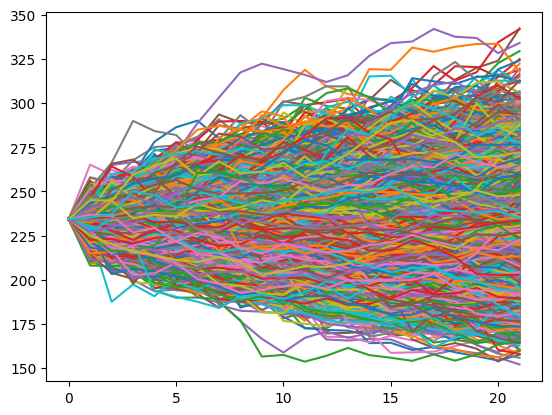

Probability price ends above $234.3: 40.1%
Last known price for AAPL: 234.3
Calculated Mean: 0.0005
Calculated Standard Dev: 0.0189
Actual closing stock price after 22 days: $234.49


In [ ]:
import warnings
warnings.filterwarnings("ignore")
import numpy as np
import matplotlib.pyplot as plt
import yfinance as yf



#PULL DATA: 
def get_data(ticker, start, end):
    data = yf.download(ticker, start = start, end = end)
    data = data.round(2)
    data.columns = data.columns.get_level_values(0)
    data = data.reset_index()
    data = data[['Date', 'Close']]
    return data


#DATA ANALYSIS: 
def get_mean(column,data):
    mean = data[column].mean()
    mean = mean.round(2)
    return mean

def get_stdDev(column, data):
    values = data[column]
    median = data[column].mean()
    sum = 0
    for i in range(len(data[column])): 
            sum+= (values[i] - median)**2
    standard_deviation=np.sqrt(sum/(len(data[column])-1))
    return standard_deviation

def get_stdError(column, data):
    standard_error = get_stdDev(column, data) / np.sqrt(len(data[column]))
    return standard_error

def get_logReturn(column, data): 
    #sets rate as an array, then adds a rate for each value of the array, and append adds an existing space to the end of the array
    rates_list = []
    for i in range(1, len(data[column])):
        r = np.log(data[column][i] / data[column][i-1])
        rates_list.append(r)
    return rates_list






#creates a mean_steps x SD_steps grid (EX: if 20 each, it would be a 20x20 grid with 400 possible hypothesis). meant to be a derived hypothesis from the data of the month

def create_hypothesis(mean_low, mean_high, mean_steps, SD_low, SD_high, SD_steps):
    mew_values = np.linspace(mean_low, mean_high, mean_steps)
    sigma_values = np.linspace(SD_low, SD_high, SD_steps)
 
    #every combination of mu and sigma becomes one hypothesis
    mean_sample = np.zeros(mean_steps * SD_steps) 
    standard_dev_sample = np.zeros(mean_steps * SD_steps)
 
    index = 0
    for i in range(mean_steps):
        for j in range(SD_steps):
            mean_sample[index] = mew_values[i]
            standard_dev_sample[index] = sigma_values[j]
            index += 1
 
    n_samples = mean_steps * SD_steps

    return mean_sample, standard_dev_sample, n_samples
#mean_sample and standard_dev_sample are lists

#mean_sample and standard_dev are the hypothesis 



#likelihood: how probable a log return is under the chosen mean and standard dev based on previous data
#choose a random mean_sasmple, and standard_dev randomly based on normal distribution 
#To determine likelihood, input it into a normal distriubtion to see the chances of mean and standard dev
def bayesian_inference(n_samples, mean_sample, standard_dev_sample, rates_list):
    prior = np.ones(n_samples) / n_samples
    rates = np.asarray(rates_list)
    n = len(rates)

    log_likelihood = np.zeros(n_samples)
    for i in range(n_samples):
        sigma = standard_dev_sample[i]
        log_likelihood[i] = (
            -n * np.log(sigma * np.sqrt(2 * np.pi))
            - 0.5 * np.sum(((rates - mean_sample[i]) / sigma) ** 2)
        )

    log_posterior_unnorm = log_likelihood + np.log(prior)
    log_posterior_unnorm -= np.max(log_posterior_unnorm)
    posterior_weights = np.exp(log_posterior_unnorm)
    posterior_weights /= np.sum(posterior_weights)

    return posterior_weights
    #posterior_weights is an array of probability that given a mean and a standard deviation, that something would occur based on the previous data 
    #one entry per hypothesis, so posterior_weights[i] includes a number between 0 and 1 is the corresponding 
    #probability of the sample mean and sample standard dev. 


#SAMPLING: Randomly choose an index in posterior_weights[] then find associating mean and std dev
#Sample a hypothesis to randomly pick an index with higher weighted priors get picked more often

#pick a mean and a standard dev using posterior_weights per simulated path then choose a random index and then find the correspond mean and standard dev for that index 
def choose_sample(n_samples, posterior_weights, mean_sample, standard_dev_sample):
    chosen_index = np.random.choice(n_samples, p=posterior_weights)
    final_mew = mean_sample[chosen_index]
    final_stdDev = standard_dev_sample[chosen_index]
    return final_mew, final_stdDev


def set_frame(graph_final):
    plt.figure()
    x = np.arange(graph_final)   
    return x


def simulate_paths(iterations_amount, graph_initial, graph_final, delta_t,
                    n_samples, posterior_weights, mean_sample, standard_dev_sample, x, jump_frequency, mean_jump, standard_dev_jump):
    mean_final = 0
    final_prices = np.zeros(iterations_amount)

    for j in range(iterations_amount):
        # Sample a pair from the posterior
        idx = np.random.choice(n_samples, p=posterior_weights)
        mu = mean_sample[idx]
        sigma = standard_dev_sample[idx]

        y = np.zeros(graph_final)
        y[0] = graph_initial

        for i in range(delta_t, graph_final, delta_t):
            diffusion = sigma * (np.sqrt(delta_t) * np.random.normal(0, 1))
             
            # Draw the number of jumps occurring in this step
            n_jumps = np.random.poisson(jump_frequency * delta_t)
            
            # Sum up the log-impact of the jumps if any occurred
            if n_jumps > 0:
                jump_effect = np.sum(np.random.normal(mean_jump, standard_dev_jump, n_jumps))
            else:
                jump_effect = 0.0

            y[i] = y[i - delta_t] * np.exp(
                (mu - 0.5 * sigma**2) * delta_t + diffusion + jump_effect
            )

        plt.plot(x, y)
        mean_final += y[-1]
        final_prices[j] = y[-1]

    mean_final /= iterations_amount
    plt.show()
    return mean_final, final_prices       


if __name__ == "__main__":
    #data pull
    ticker = "AAPL"
    start, end = "2025-01-01", "2025-02-01" #inputed data 
    data = get_data(ticker, start, end)
    final_price_compare = get_data(ticker, "2025-03-04", "2025-03-05") #price to compare finally after trading days

    
    # basic stats 
    mean_price = get_mean("Close", data)
    std_price = get_stdDev("Close", data)
    std_error = get_stdError("Close", data)
    rates_list = get_logReturn("Close", data)

    #Hypothesis
    mean_low, mean_high, mean_steps = -0.002, 0.002, 100
    SD_low, SD_high, SD_steps = 0.005, 0.035, 100

    #Jump Variables: small chance for unexpected jump or drops
    jump_frequency = 0.05 #5% chance of jump on every day
    mean_jump = -0.02 #2% jump 
    standard_dev_jump = 0.03 #how much the jump varies 


    mean_sample, standard_dev_sample, n_samples = create_hypothesis(
        mean_low, mean_high, mean_steps, SD_low, SD_high, SD_steps
    )

    # Bayesian inference
    posterior_weights = bayesian_inference(n_samples, mean_sample, standard_dev_sample, rates_list)
    final_mew, final_stdDev = choose_sample(n_samples, posterior_weights, mean_sample, standard_dev_sample)

    # Simulation
    graph_initial = data["Close"].iloc[-1]   # start simulation from last known price
    graph_final = 22                        # amount of trading days to simulate
    delta_t = 1
    iterations_amount = 10000

    x = set_frame(graph_final)
    mean_final, final_prices = simulate_paths(
    iterations_amount, graph_initial, graph_final, delta_t,
    n_samples, posterior_weights, mean_sample, standard_dev_sample, x, jump_frequency, mean_jump, standard_dev_jump)

    threshold = 234.3  #price to determine percentile 
    prob_above = np.mean(final_prices > threshold) * 100
    print(f"Probability price ends above ${threshold}: {prob_above:.1f}%")


    last_known_price = data["Close"].iloc[-1]
    print(f"Last known price for {ticker}: ${last_known_price}")
    print(f"Calculated Mean: {final_mew:.4f}")
    print(f"Calculated Standard Dev: {final_stdDev:.4f}")
    actual_price = final_price_compare["Close"].iloc[0]
    print(f"Actual closing stock price after {graph_final} days: ${actual_price:.2f}")
